<a href="https://colab.research.google.com/github/ayusshs/Diabetes-Prediction-ML/blob/main/Diabetes_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Making the Most of your Colab Subscription



In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [4]:
# Loading the diabetes dataset
diabetes_dataset = pd.read_csv('/content/diabetes.csv')
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
diabetes_dataset.describe()
diabetes_dataset.isnull().sum()
diabetes_dataset['Outcome'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count
Outcome,
0,500
1,268


In [6]:
diabetes_dataset.shape

(768, 9)

In [7]:
diabetes_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


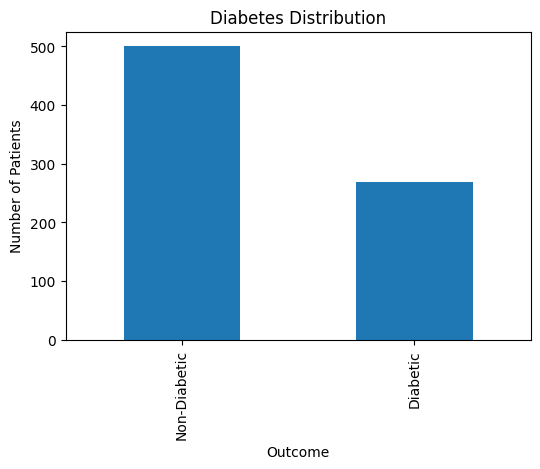

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
diabetes_dataset['Outcome'].value_counts().plot(kind='bar')

plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["Non-Diabetic", "Diabetic"])

plt.show()

In [10]:
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [11]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [12]:
Y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [13]:
print(X.shape)
print(Y.shape)

(768, 8)
(768,)


In [14]:
scaler = StandardScaler()

In [15]:
scaler.fit(X)

StandardScaler()

In [16]:
standardized_data = scaler.transform(X)

In [17]:
X = standardized_data

In [18]:
print(X)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=2
)

In [20]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

print(Y_train.shape)
print(Y_test.shape)

(768, 8)
(614, 8)
(154, 8)
(614,)
(154,)


In [21]:
classifier = svm.SVC(kernel='linear')

In [22]:
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

In [23]:
X_train_prediction = classifier.predict(X_train)

training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

print("Accuracy score of the training data :", training_data_accuracy)

Accuracy score of the training data : 0.7866449511400652


In [24]:
X_test_prediction = classifier.predict(X_test)

test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

print("Accuracy score of the test data :", test_data_accuracy)

Accuracy score of the test data : 0.7727272727272727


In [25]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# Change to NumPy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape because we are predicting one patient
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# Standardize using the same scaler
std_data = scaler.transform(input_data_reshaped)

prediction = classifier.predict(std_data)

print(prediction)

if prediction[0] == 0:
    print("The person is not diabetic")
else:
    print("The person is diabetic")

[1]
The person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
import seaborn as sns

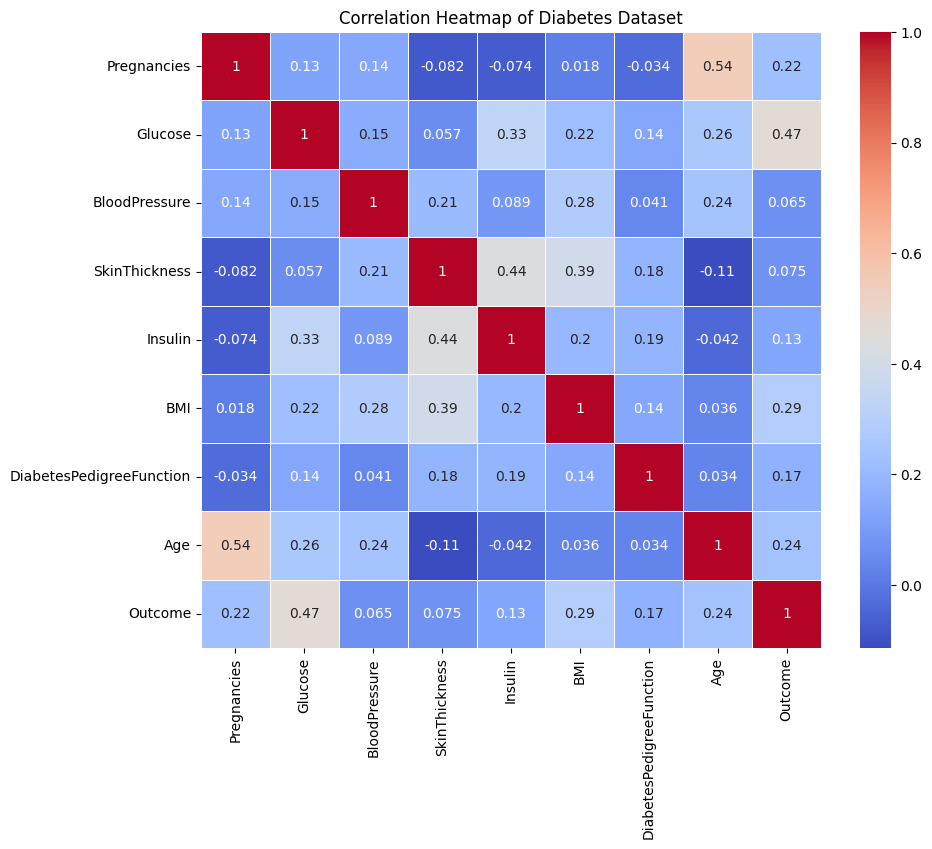

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    diabetes_dataset.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()



```
## Heatmap Analysis

The correlation heatmap shows that:

- Glucose has the highest positive correlation (0.47) with diabetes outcome.
- BMI and Age also show moderate positive correlations.
- Blood Pressure and Skin Thickness have relatively weak correlations.
- There is no extremely high correlation between input features, indicating that severe multicollinearity is not present.

This analysis suggests that glucose is the most influential feature for predicting diabetes in this dataset.
```



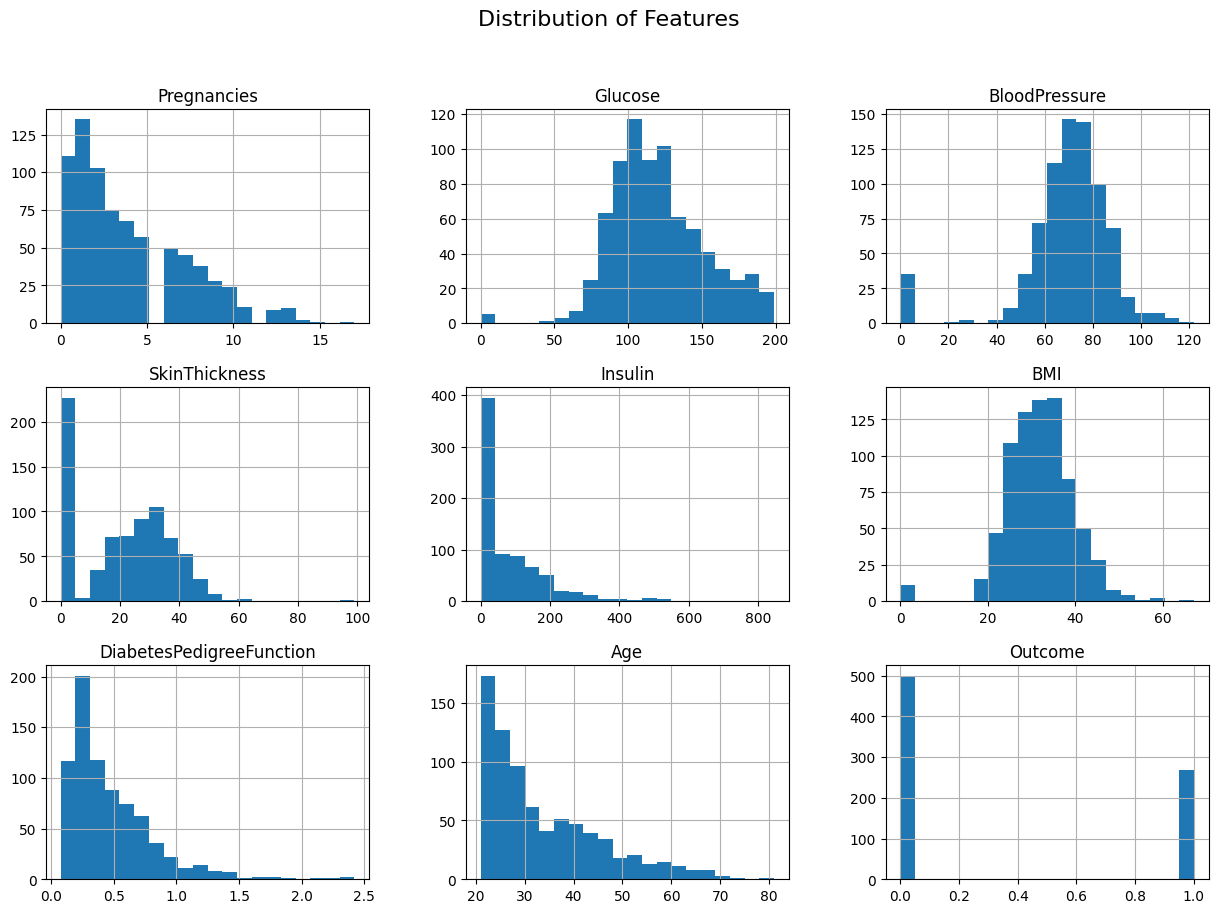

In [28]:
import matplotlib.pyplot as plt

diabetes_dataset.hist(figsize=(15,10), bins=20)

plt.suptitle("Distribution of Features", fontsize=16)

plt.show()

## Histogram Analysis

The histograms show that:

- Most patients are between 20–40 years old.
- Glucose values are concentrated around 90–140.
- Several features (Glucose, BloodPressure, SkinThickness, Insulin, BMI) contain zero values, which are likely placeholders for missing data.
- The Outcome variable is imbalanced, with more non-diabetic patients than diabetic patients.

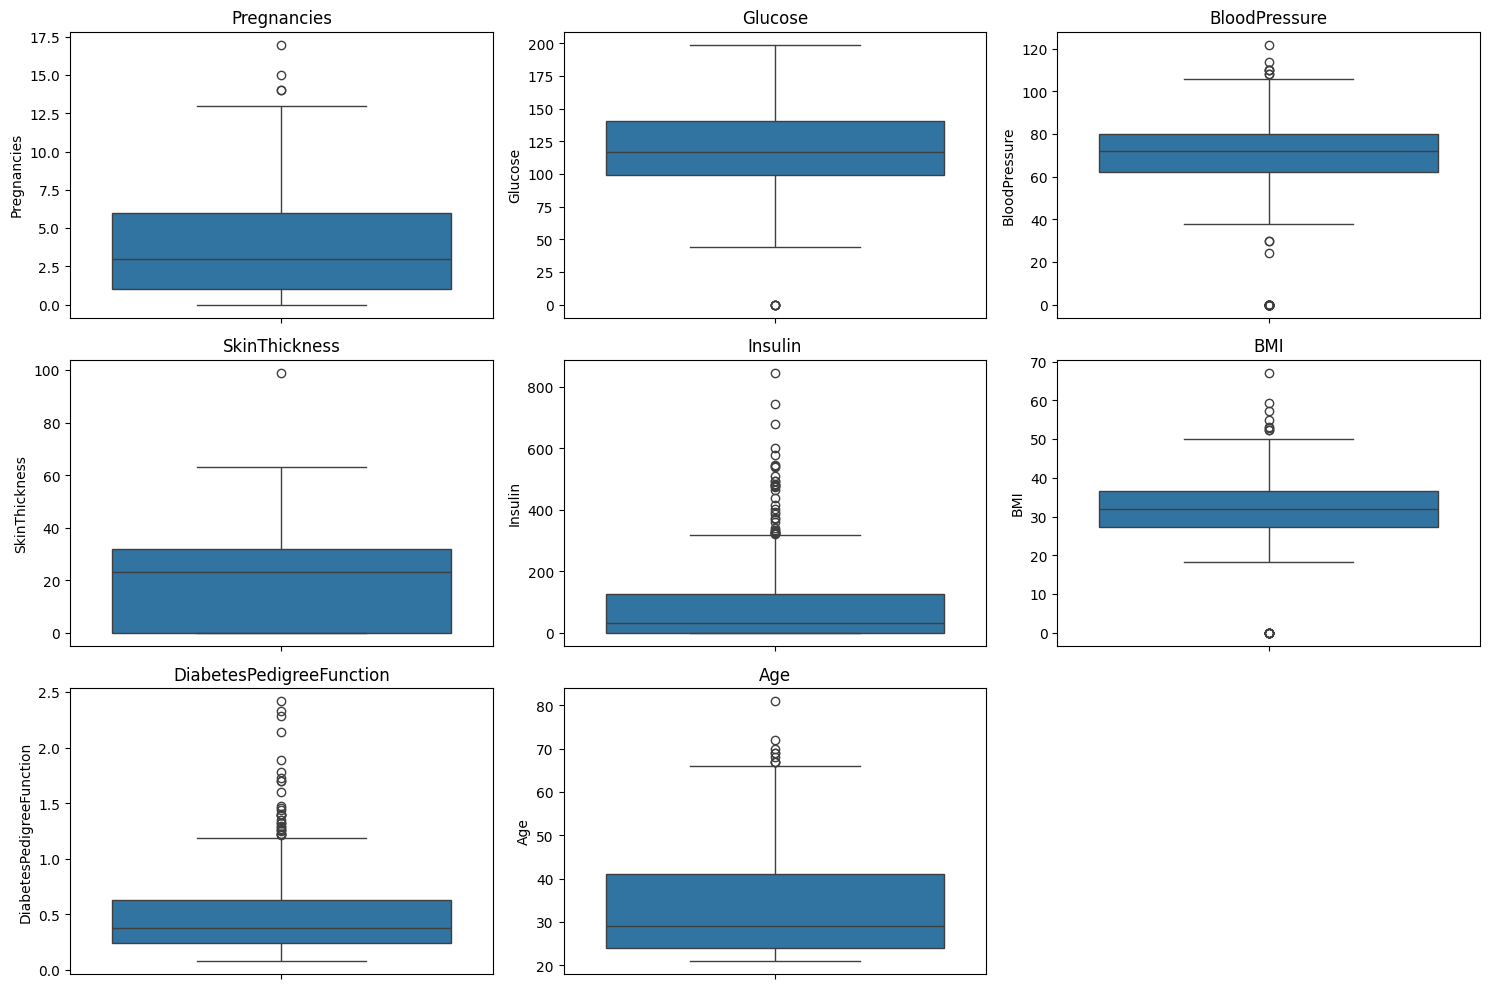

In [29]:
plt.figure(figsize=(15,10))

for i, column in enumerate(diabetes_dataset.columns[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=diabetes_dataset[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=2),
    "Random Forest": RandomForestClassifier(random_state=2),
    "Support Vector Machine": svm.SVC(kernel='linear')
}

In [32]:
results = {}

for name, model in models.items():
    model.fit(X_train, Y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(Y_test, prediction)

    results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.7597
Decision Tree: 0.6948
Random Forest: 0.7273
Support Vector Machine: 0.7727


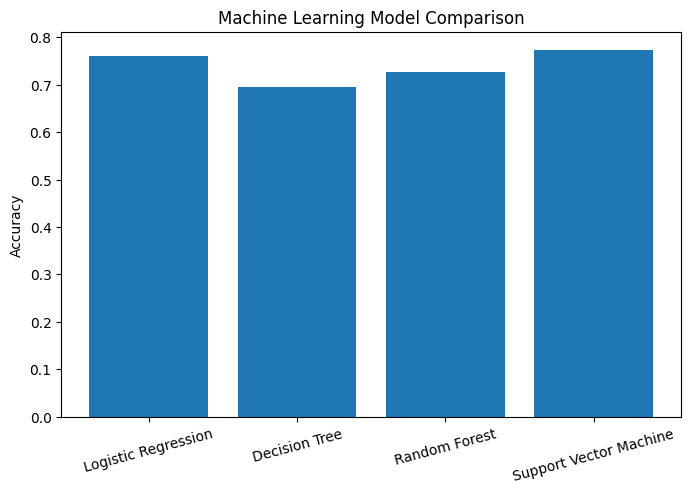

In [33]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.ylabel("Accuracy")
plt.title("Machine Learning Model Comparison")

plt.xticks(rotation=15)

plt.show()

In [34]:
import joblib

joblib.dump(classifier, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler Saved Successfully!")

Model and Scaler Saved Successfully!


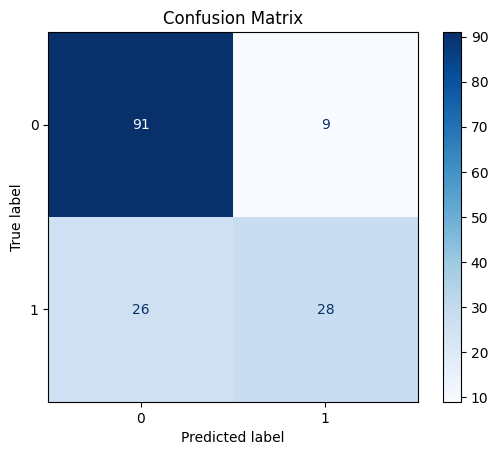

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, X_test_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       100
           1       0.76      0.52      0.62        54

    accuracy                           0.77       154
   macro avg       0.77      0.71      0.73       154
weighted avg       0.77      0.77      0.76       154

